# 06 · Meet py_trees

## Learning objectives

- Map the teaching engine to a maintained library.
- Use composites, leaves, and a tree owner.
- Read status diagrams.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

Our engine explained traversal, but did not fully manage interruption, resource setup,
or diagnostics. `py_trees` supplies these mechanisms. Its spelling is `Behaviour`, and its
leaf work method is `update()`. A composite still has the same sequence or selector rule.
A `BehaviourTree` owns ticking and can attach visitors; it is not a ROS node.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

RUNNING
RUNNING
SUCCESS


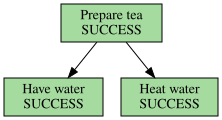

In [3]:
def factory():
    return pt.composites.Sequence("Prepare tea", memory=False, children=[
        pt.behaviours.Success("Have water"),
        CountTicks("Heat water", ticks=3),
    ])

root = factory()
tree = pt.trees.BehaviourTree(root)
tree.setup(timeout=5.0)
for _ in range(3):
    tree.tick()
    print(root.status.name)
assert root.status is Status.SUCCESS
display(diagram(root))
tree.shutdown()

## Step-by-step implementation
`tick_once()` is convenient for one root. `BehaviourTree.tick()` also runs registered
visitors and handlers. Both eventually call `update()` on leaves. The library owns status
transitions; do not call a leaf's `update()` directly to simulate a complete tick.

| Teaching engine | py_trees | Why it exists |
|---|---|---|
| Action(function) | Behaviour.update | Leaf work |
| Sequence(memory=...) | composites.Sequence | Control flow |
| reset status | stop(INVALID) | Lifecycle-aware interruption |
| root.tick() | BehaviourTree.tick() | Managed traversal |

In [4]:
from behavior_trees_tutorial.trees.core import Action, Sequence, Status as SimpleStatus
simple = Sequence("Task", [Action("Ready", lambda: SimpleStatus.SUCCESS)])
library = pt.composites.Sequence("Task", memory=False, children=[pt.behaviours.Success("Ready")])
simple.tick(); library.tick_once()
assert simple.status.name == library.status.name == "SUCCESS"

## Interactive demonstration

In [5]:
display(playground(factory))

## Key observations

A library earns its complexity by managing details our tiny engine intentionally omits. The decision rules remain recognizable.

## Exercises

1. Replace Have water with Failure.
2. Compare a library selector with lesson 4 for the same inputs.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 06).

## Summary

We now have dependable building blocks. Next we will write a leaf that participates correctly in their lifecycle.